In [2]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import lovely_tensors as lt
lt.monkey_patch()
import imageio.v3 as iio
import torch

from hmr4d.utils.pylogger import Log
import hydra
from hydra import compose, initialize_config_module
from hydra.core.global_hydra import GlobalHydra
from hmr4d.configs import register_store_gvhmr
from hmr4d.model.gvhmr.gvhmr_pl_demo import DemoPL

from hmr4d.utils.preproc import Tracker, Extractor, VitPoseExtractor, SimpleVO
from hmr4d.utils.geo.hmr_cam import get_bbx_xys_from_xyxy, estimate_K
from hmr4d.utils.preproc.vitpose_pytorch.src.vitpose_infer.pose_utils.pose_viz import joints_dict
from hmr4d.utils.geo_transform import compute_cam_angvel, move_to_start_point_face_z
from hmr4d.utils.body_model import BodyModelSMPLX
from hmr4d.utils.body_model.smplx_lite import SmplxLiteV437Coco17
from hmr4d.utils.vis.renderer import Renderer
from hmr4d.utils.vis.cv2_utils import draw_bbx_xyxy_on_image_batch, draw_kpts_with_conf_batch


/home/guangyu/anaconda3/envs/hmr/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
# GlobalHydra.instance().clear()
with initialize_config_module(version_base="1.3", config_module="hmr4d.configs"):
    register_store_gvhmr()
    cfg = compose(config_name="demo")
    
model = hydra.utils.instantiate(cfg.model, _recursive_=False)
model.load_pretrained_model(cfg.ckpt_path)
model = model.eval().cuda()

/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/network/base_arch/embeddings/rotary_embedding_v2.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/pipeline/gvhmr_pipeline.py:321: FutureWarning: `to

In [4]:
smplx = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="neutral", num_pca_comps=12, flat_hand_mean=False,
).cuda()
smplx_coco = SmplxLiteV437Coco17().cuda()

tracker = Tracker()
vitpose_extractor = VitPoseExtractor()
extractor = Extractor()

/home/guangyu/anaconda3/envs/hmr/lib/python3.10/site-packages/ultralytics/nn/tasks.py:775: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location

In [5]:
video_path = Path("/data/datasets/Chippy_medical/2025_10-11/1360.mp4")
output_path = Path("/data/datasets/Chippy_medical/2025_10-11_results")
output_path.mkdir(exist_ok=True, parents=True)

length, height, width, c = iio.improps(video_path, plugin="pyav").shape
if length == 0:
    video = cv2.VideoCapture(str(video_path))
    fps = video.get(cv2.CAP_PROP_FPS)
    length = int(video.get(cv2.CAP_PROP_FRAME_COUNT))-1
print(f"{str(video_path)}: {width}x{height}x{length}")

# final_results = torch.load(output_path / f"{video_path.stem}.pt")

/data/datasets/Chippy_medical/2025_10-11/1360.mp4: 3840x2160x2444


In [6]:
track_history = tracker.track(video_path)
vid_length = len(track_history)
id_to_frame_ids, id_to_bbx_xyxys, id_sorted = tracker.sort_track_length(track_history, video_path)

for k in id_sorted:
    lst = id_to_frame_ids[k]
    ranges = np.split(lst, np.where(np.diff(lst)!=1)[0]+1)
    ranges = [(x[0], x[-1]) if len(x) > 1 else (x[0], x[0]) for x in ranges]
    print(f"track id {k}: {len(lst)} frames, ranges: {ranges}")

YoloV8 Tracking: 100%|██████████| 2444/2444 [02:49<00:00, 14.43it/s]


track id 1: 2439 frames, ranges: [(0, 1689), (1691, 2362), (2367, 2443)]
track id 2: 2444 frames, ranges: [(0, 2443)]


In [7]:
track_ids = [2]
frame_ids, bbx_xyxys = [], []
for track_id in track_ids:
    tmp_id = torch.tensor(id_to_frame_ids[track_id])  # (N,)
    frame_ids.append(tmp_id)
    tmp_xyxy = torch.tensor(id_to_bbx_xyxys[track_id])  # (N, 4)
    bbx_xyxys.append(tmp_xyxy)
frame_ids = torch.cat(frame_ids)
bbx_xyxys = torch.cat(bbx_xyxys)

bbx_xyxy = tracker.interpolate_smooth_bbx(frame_ids, bbx_xyxys, length=vid_length)
bbx_xys = get_bbx_xys_from_xyxy(bbx_xyxy, base_enlarge=1.2).float()

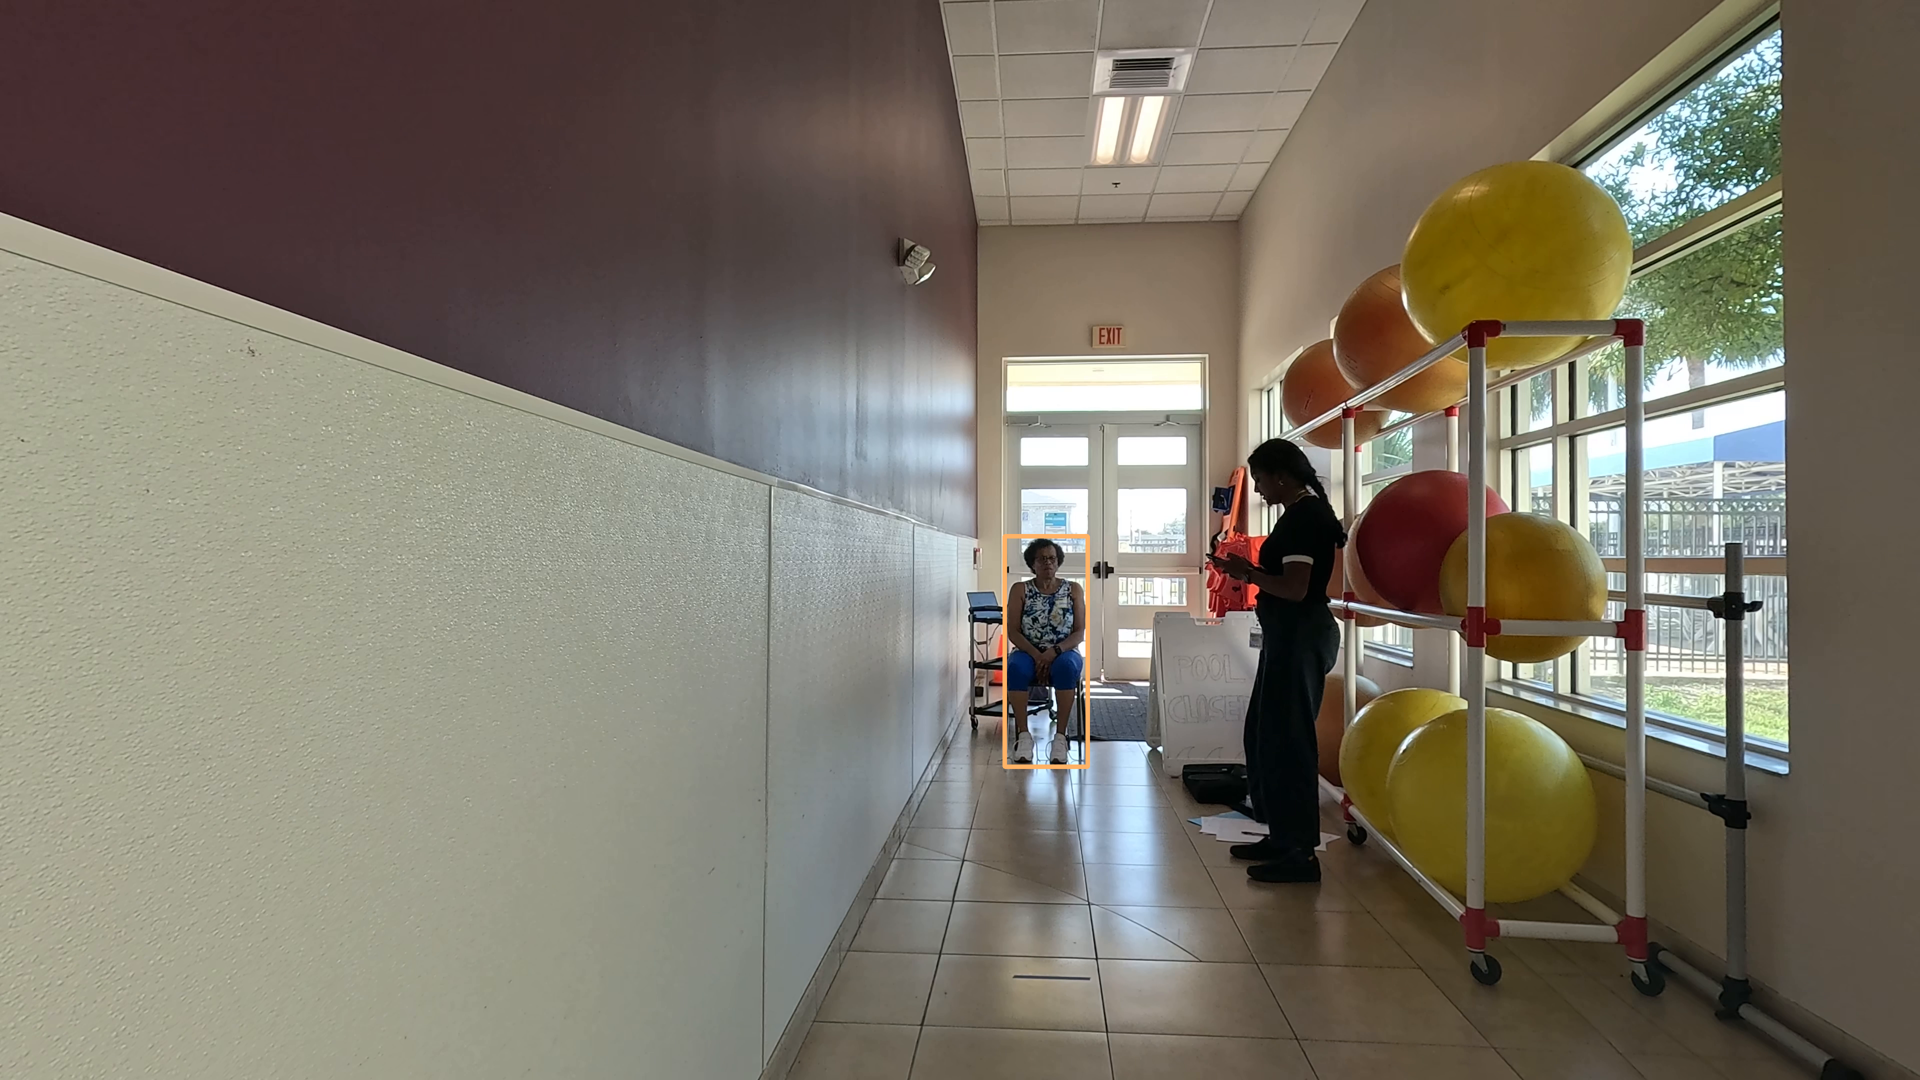

In [8]:
i = 120
img = iio.imread(video_path, index=i)  # (L, H, W, 3) RGB
video_overlay = draw_bbx_xyxy_on_image_batch(bbx_xyxy[i:i+1], [img], thickness=8)
Image.fromarray(video_overlay[0]).resize((width // 2, height // 2))

In [ ]:
vitpose = vitpose_extractor.extract(str(video_path), bbx_xys) # (L, 17, 3)
vit_features = extractor.extract_video_features(str(video_path), bbx_xys) # (L, 1024)

simple_vo = SimpleVO(video_path, scale=0.5, step=8, method="sift", f_mm=None)
vo_results = simple_vo.compute() # (L, 4, 4)
R_w2c = torch.from_numpy(vo_results[:, :3, :3]) # (L, 3, 3)
K_fullimg = estimate_K(width, height).repeat(length, 1, 1) # (L, 3, 3)

ViTPose: 100%|██████████| 153/153 [01:51<00:00,  1.37it/s]


[SimpleVO] Choosen frames shape: (307, 1080, 1920, 3)
TwoViewGeometryOptions:
    min_num_inliers = 10
    min_E_F_inlier_ratio = 0.8
    max_H_inlier_ratio = 0.9
    watermark_min_inlier_ratio = 0.7
    watermark_border_size = 0.1
    detect_watermark = True
    multiple_ignore_watermark = True
    watermark_detection_max_error = 4.0
    filter_stationary_matches = False
    stationary_matches_max_error = 4.0
    force_H_use = False
    compute_relative_pose = True
    multiple_models = False
    ransac: RANSACOptions:
        max_error = 4.0
        min_inlier_ratio = 0.25
        confidence = 0.999
        dyn_num_trials_multiplier = 3.0
        min_num_trials = 100
        max_num_trials = 10000
        random_seed = -1


  7%|▋         | 21/306 [00:20<04:35,  1.03it/s]

In [ ]:
data = {
    "length": torch.tensor(length),
    "bbx_xys": bbx_xys,
    "kp2d": vitpose,
    "K_fullimg": K_fullimg,
    "cam_angvel": compute_cam_angvel(R_w2c),
    "f_imgseq": vit_features,
}
pred = model.predict(data, static_cam=False)

final_results = {
    "input_video" : str(video_path.absolute()),
    'model_dir': str(cfg.ckpt_path),
    "dimensions" : (length, width, height),
    "bbx_xyxy": bbx_xyxy, "bbx_xys": bbx_xys,
    "vitpose": vitpose,
    'vit_features': vit_features,
    'R_w2c': R_w2c,
    'K_fullimg': K_fullimg,
    'smpl_params_global' : {k:v.cpu() for k,v in pred["smpl_params_global"].items()},
    'smpl_params_incam' : {k:v.cpu() for k,v in pred["smpl_params_incam"].items()},
}
torch.save(final_results, output_path / f"{video_path.stem}.pt")

In [ ]:
renderer_c = Renderer(width, height, device="cuda", faces=smplx.faces, K=estimate_K(width, height))

df = []
for frame in range(len(final_results['vitpose'])):
    part = final_results['vitpose'][frame]
    sub_df = [[frame, i, joints_dict()['coco']['keypoints'].get(i, 'None'), f"{row[0]:.6f}", f"{row[1]:.6f}", f"{row[2]:.4f}"] for i, row in enumerate(part)]
    df.extend(sub_df)
df = pd.DataFrame(df, columns=['frame', 'joint_idx', 'joint_name', 'x', 'y', 'confidence'])
df.to_csv(output_path / f"{video_path.stem}_vitpose.csv", index=False)

smplx_coco_camera_verts, smplx_coco_camera_joints = smplx_coco(**pred['smpl_params_incam'])
smplx_coco_camera_joints, smplx_coco_camera_valid = renderer_c.project_points_to_full_image(smplx_coco_camera_joints)

smplx_coco_global_verts, smplx_coco_global_joints  = smplx_coco(**pred["smpl_params_global"], return_all_verts=True)
smplx_coco_global_verts, smplx_coco_global_joints = move_to_start_point_face_z(
    smplx_coco_global_verts[..., :132, :], 
    smplx_coco.smplx2coco17_interestd.T,
    hip_j = [11, 12], 
    shoulder_j = [5, 6]
)
df = []
for frame in range(len(smplx_coco_camera_joints)):
    part = smplx_coco_camera_joints[frame]
    sub_df = [[frame, i, joints_dict()['coco']['keypoints'].get(i, 'None'), f"{row[0]:.6f}", f"{row[1]:.6f}"] for i, row in enumerate(part)]
    df.extend(sub_df)
df = pd.DataFrame(df, columns=['frame', 'joint_idx', 'joint_name', 'x', 'y'])
df.to_csv(output_path / f"{video_path.stem}_coco_camera_joints.csv", index=False)

df = []
for frame in range(len(smplx_coco_global_joints)):
    part = smplx_coco_global_joints[frame]
    sub_df = [[frame, i, joints_dict()['coco']['keypoints'].get(i, 'None'), f"{row[0]:.6f}", f"{row[1]:.6f}", f"{row[2]:.6f}"] for i, row in enumerate(part)]
    df.extend(sub_df)
df = pd.DataFrame(df, columns=['frame', 'joint_idx', 'joint_name', 'x', 'y', 'z'])
df.to_csv(output_path / f"{video_path.stem}_coco_global_joints.csv", index=False)

In [ ]:
# smpl
smplx_out = smplx(**{k: v.to('cuda') for k, v in final_results['smpl_params_incam'].items()})

i = 60
img_raw = cv2.resize(iio.imread(video_path, index=i), (width, height))
img_annot = draw_bbx_xyxy_on_image_batch(final_results['bbx_xyxy'][i:i+1], [img_raw], thickness=8)[0]
img_annot = draw_kpts_with_conf_batch(
    [img_annot[..., ::-1]], final_results['vitpose'][i:i+1, ..., :2], 
                            final_results['vitpose'][i:i+1, ...,  2], thickness=8)[0][...,::-1]

img_cam = renderer_c.render_mesh(smplx_out.vertices[i].cuda(), img_raw)
img_debug = Image.fromarray(np.concatenate([img_annot, img_cam], axis=1))
img_debug.save(output_path / f"{video_path.stem}_{i}_debug.jpg")
img_debug

In [ ]:
# from hmr4d.utils.preproc.relpose.solver_two_view import TwoPairSolver, CameraParams, interpolate_missing_frames
# from hmr4d.utils.preproc.relpose.matcher_wrapper import Matcher
# from hmr4d.utils.preproc.relpose.utils import focal_length_from_mm
# from hmr4d.utils.video_io_utils import read_video_np

# frames = read_video_np(video_path, scale=0.5, rotate=0)
# F_all = frames.shape[0]
# sample_idxs = np.arange(0, F_all, 8)
# if sample_idxs[-1] != F_all - 1:
#     sample_idxs = np.concatenate([sample_idxs, [F_all - 1]])
# frames = frames[sample_idxs]
# F, H, W, C = frames.shape
# print(f"[SimpleVO] Choosen frames shape: {frames.shape}")

# matcher: Matcher = Matcher('sift')
# camera_params = CameraParams(W, H, focal_length=focal_length_from_mm(W, H, 24))
# solver = TwoPairSolver(camera_params, solver="pycolmap")

# T_w2c_list = [np.eye(4)]
# prev_frame = frames[0]
# for frame_idx in tqdm(range(1, len(frames))):
#     curr_frame = frames[frame_idx]
#     pts0, pts1 = matcher.match_np(prev_frame, curr_frame)
#     T_delta = solver.solve(pts0, pts1)  # T_delta = T_curr @ T_last^-1
#     T_w2c_list.append(T_delta @ T_w2c_list[-1])
#     prev_frame = curr_frame